# InceptionV3 — 10- and 20-epoch experiments

Training and evaluation of InceptionV3 transfer-learning experiments for binary tuberculosis classification from chest X-ray images.

**Dataset path expected:** `data/TB_Chest_Radiography_Database/`.


Found 4900 validated image filenames.
Found 1050 validated image filenames.
Found 1050 validated image filenames.
Epoch 1/10


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


154/154 ━━━━━━━━━━━━━━━━━━━━ 1634s 10s/step - accuracy: 0.7572 - loss: 0.4847 - val_accuracy: 0.9524 - val_loss: 0.1326
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1690s 11s/step - accuracy: 0.9432 - loss: 0.1628 - val_accuracy: 0.9676 - val_loss: 0.0899
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1597s 10s/step - accuracy: 0.9576 - loss: 0.1338 - val_accuracy: 0.9648 - val_loss: 0.0937
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1649s 11s/step - accuracy: 0.9616 - loss: 0.1067 - val_accuracy: 0.9743 - val_loss: 0.0726
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1662s 11s/step - accuracy: 0.9671 - loss: 0.0888 - val_accuracy: 0.9629 - val_loss: 0.0997
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1678s 11s/step - accuracy: 0.9722 - loss: 0.0803 - val_accuracy: 0.9800 - val_loss: 0.0437
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1648s 10s/step - accuracy: 0.9757 - loss: 0.0732 - val_accuracy: 0.9800 - val_loss: 0.0534
Epoch 8/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1772s 11s/step - accuracy: 0.9748 - loss: 0.0706 - val

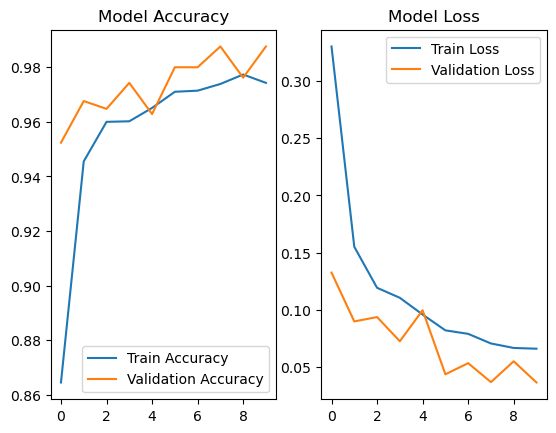

33/33 ━━━━━━━━━━━━━━━━━━━━ 193s 6s/step - accuracy: 0.9841 - loss: 0.0463
Test Accuracy: 97.90%
Test Loss: 0.0597
33/33 ━━━━━━━━━━━━━━━━━━━━ 256s 7s/step


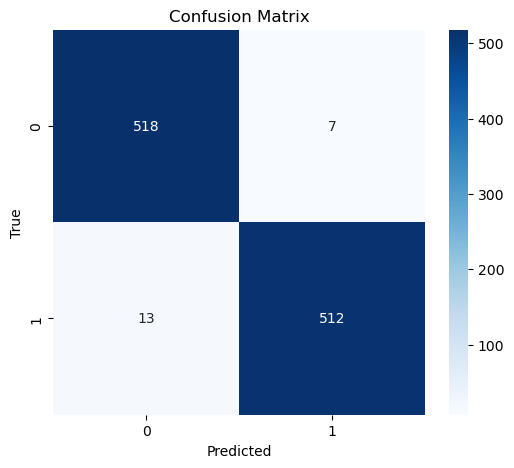


Classification Report:
               precision    recall  f1-score   support

      Normal       0.98      0.99      0.98       525
          TB       0.99      0.98      0.98       525

    accuracy                           0.98      1050
   macro avg       0.98      0.98      0.98      1050
weighted avg       0.98      0.98      0.98      1050



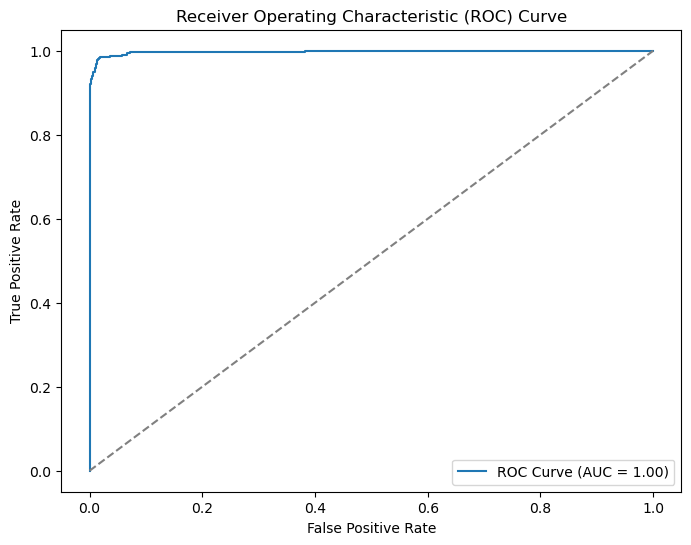

In [ ]:
#10 Epochs InceptionV3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Step 1: Define dataset path
base_path = r'data/TB_Chest_Radiography_Database'

# #####Step 2: Load and preprocess data
image_paths = []
labels = []
categories = ['Normal', 'Tuberculosis']

for category in categories:
    folder_path = os.path.join(base_path, category)
    for file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, file))
        labels.append(category)

# #######Step 3: Create DataFrame####
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df['label'] = df['label'].map({'Normal': 0, 'Tuberculosis': 1})

# **Step 4: Split dataset**
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

########Step 5: Data Augmentation#########
data_gen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = data_gen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label', target_size=(299, 299), batch_size=32,
    class_mode='raw', shuffle=True
)

val_generator = data_gen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='label', target_size=(299, 299), batch_size=32,
    class_mode='raw', shuffle=False
)

test_generator = data_gen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label', target_size=(299, 299), batch_size=32,
    class_mode='raw', shuffle=False
)

# Step 6: Load InceptionV3 (Pretrained)
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze the base model

########Step 7: Build the Model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

#########Step 8: Compile Model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Step 9: Train Model######
history = model.fit(train_generator, validation_data=val_generator, epochs=10)


# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()
# ####Step 12: Evaluate on Test Set######
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")  # Added test loss output

######3Step 13: Confusion Matrix & Classification Report#####
y_true = test_df['label'].values  
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

######Step 14: ROC Curve#####
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [5]:
model.save("InceptionV3_model_name.h5")  # Change to any name you prefer


In [7]:
from tensorflow.keras.models import load_model

model = load_model("InceptionV3_model_name.h5")  # Or use .keras if you saved in that format
print("Model loaded successfully!")


Model loaded successfully!


Found 4900 validated image filenames.
Found 1050 validated image filenames.
Found 1050 validated image filenames.
Epoch 1/20


C:\Users\usER\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


154/154 ━━━━━━━━━━━━━━━━━━━━ 2267s 14s/step - accuracy: 0.7911 - loss: 0.4445 - val_accuracy: 0.9543 - val_loss: 0.1344
Epoch 2/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1758s 11s/step - accuracy: 0.9446 - loss: 0.1565 - val_accuracy: 0.9638 - val_loss: 0.0930
Epoch 3/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1395s 9s/step - accuracy: 0.9571 - loss: 0.1204 - val_accuracy: 0.9743 - val_loss: 0.0716
Epoch 4/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1537s 10s/step - accuracy: 0.9627 - loss: 0.1005 - val_accuracy: 0.9781 - val_loss: 0.0659
Epoch 5/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1559s 10s/step - accuracy: 0.9625 - loss: 0.1033 - val_accuracy: 0.9752 - val_loss: 0.0685
Epoch 6/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1562s 10s/step - accuracy: 0.9687 - loss: 0.0959 - val_accuracy: 0.9800 - val_loss: 0.0612
Epoch 7/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1496s 10s/step - accuracy: 0.9721 - loss: 0.0804 - val_accuracy: 0.9848 - val_loss: 0.0461
Epoch 8/20
154/154 ━━━━━━━━━━━━━━━━━━━━ 1574s 10s/step - accuracy: 0.9720 - loss: 0.0719 - val_

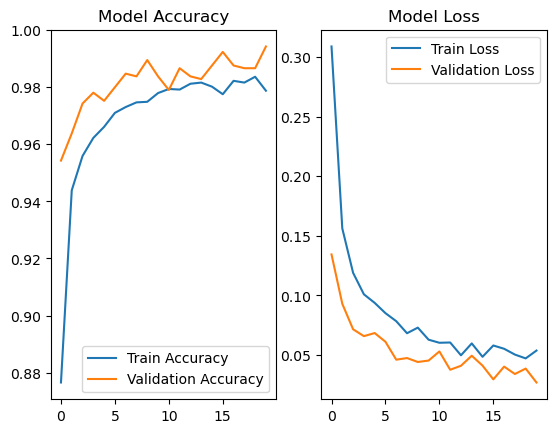

33/33 ━━━━━━━━━━━━━━━━━━━━ 244s 7s/step - accuracy: 0.9910 - loss: 0.0322
Test Accuracy: 98.86%
Test Loss: 0.0400
33/33 ━━━━━━━━━━━━━━━━━━━━ 284s 8s/step


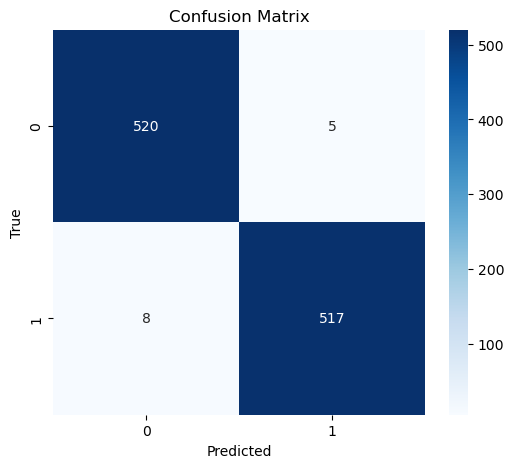


Classification Report:
               precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       525
          TB       0.99      0.98      0.99       525

    accuracy                           0.99      1050
   macro avg       0.99      0.99      0.99      1050
weighted avg       0.99      0.99      0.99      1050



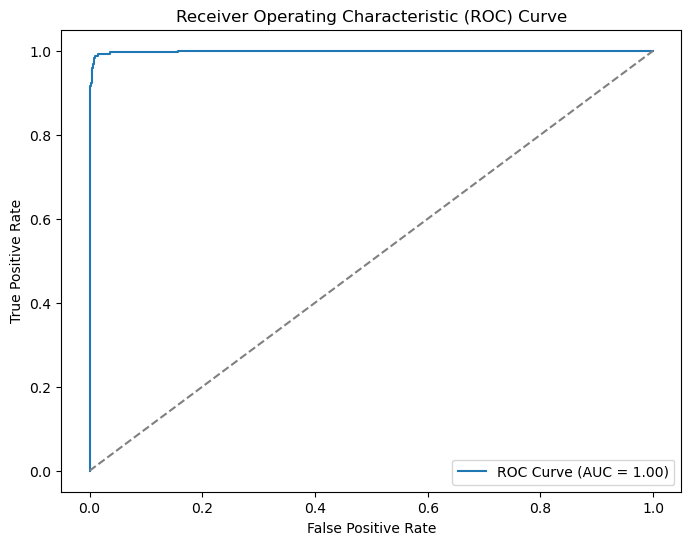

In [1]:
# 20 EPOCHS InceptionV3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# **Step 1: Define dataset path**
base_path = r'data/TB_Chest_Radiography_Database'

# **Step 2: Load and preprocess data**
image_paths = []
labels = []
categories = ['Normal', 'Tuberculosis']

for category in categories:
    folder_path = os.path.join(base_path, category)
    for file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, file))
        labels.append(category)

# **Step 3: Create DataFrame**
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
df['label'] = df['label'].map({'Normal': 0, 'Tuberculosis': 1})

# **Step 4: Split dataset**
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

# **Step 5: Data Augmentation**
data_gen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = data_gen.flow_from_dataframe(
    train_df, x_col='image_path', y_col='label', target_size=(299, 299), batch_size=32,
    class_mode='raw', shuffle=True
)

val_generator = data_gen.flow_from_dataframe(
    val_df, x_col='image_path', y_col='label', target_size=(299, 299), batch_size=32,
    class_mode='raw', shuffle=False
)

test_generator = data_gen.flow_from_dataframe(
    test_df, x_col='image_path', y_col='label', target_size=(299, 299), batch_size=32,
    class_mode='raw', shuffle=False
)

# **Step 6: Load InceptionV3 (Pretrained)**
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze the base model

# **Step 7: Build the Model**
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# **Step 8: Compile Model**
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# **Step 9: Train Model**
history = model.fit(train_generator, validation_data=val_generator, epochs=20)


# Step 11: Training and Validation Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
# **Step 12: Evaluate on Test Set**
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")  # Added test loss output

# **Step 13: Confusion Matrix & Classification Report**
y_true = test_df['label'].values  
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'TB']))

# **Step 14: ROC Curve**
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred)

plt.figure()
plt.plot(recall, precision, label="Precision-Recall curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

In [14]:
import numpy as np

dummy_input = np.random.rand(1, 299, 299, 3)  # Replace with your model’s expected input shape
model.predict(dummy_input)  # This initializes the model


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


array([[0.9996008]], dtype=float32)

In [4]:
model.save("tb_inceptionv3_model20.h5")
print("Model saved successfully!")


Model saved successfully!


In [7]:
from tensorflow.keras.models import load_model

model = load_model('tb_inceptionv3_model20.h5')  # Load model for Grad-CAM

In [9]:
for layer in model.layers:
    print(layer.name)


inception_v3
global_average_pooling2d
dense
dropout
dense_1
dropout_1
dense_2
